In [1]:
pip install numpy pandas matplotlib scipy scikit-learn wfdb streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
import wfdb
import streamlit as st
print("all libraries imported successfully!")
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("scikit-learn version:", sklearn.__version__)


all libraries imported successfully!
numpy version: 2.1.3
pandas version: 2.2.3
scikit-learn version: 1.6.1


In [3]:
import os
folder=["CardioGuard_ai/data",
        "CardioGuard_ai/models",
        "CardioGuard_ai/outputs"
        ]
for folder in folder:
    os.makedirs(folder,exist_ok=True)
print("project folder created successfully!")


project folder created successfully!


(0.0, 10.0)

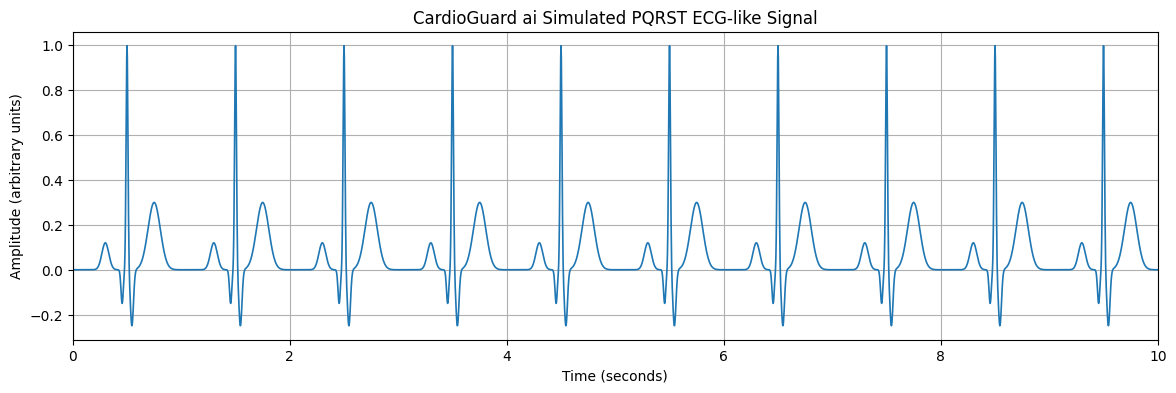

In [4]:
import numpy as np
import matplotlib.pyplot as plt
fs=360
duration=10
t=np.arange(0,duration,1/fs)
ecg=np.zeros_like(t)
for beat in np.arange(0.5, duration, 1.0):
  x=t-beat
  ecg+=0.12*np.exp(-((x+0.20)/ 0.045)**2)
  ecg+=-0.15*np.exp(-((x+0.045)/ 0.015)**2)
  ecg+=1.00*np.exp(-(x/0.012)**2)
  ecg+=-0.25*np.exp(-((x-0.045)/ 0.020)**2)
  ecg+=0.30*np.exp(-((x-0.25)/ 0.080)**2)
plt.figure(figsize=(14,4))
plt.plot(t,ecg,linewidth=1.2)
plt.title("CardioGuard ai Simulated PQRST ECG-like Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (arbitrary units)")
plt.grid(True)
plt.xlim(0,duration)

In [6]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
record=wfdb.rdrecord("100",pn_dir="mitdb")
ecg_signal=record.p_signal[:,0]
fs=record.fs
time=np.arange(len(ecg_signal))/fs
print("ECG record loaded successfully!")
print("Record name:", record.record_name)
print("Sampling freque:",fs,"HZ")
print("Total samples:",round(len(ecg_signal)/fs,2),"seconds")
print("ECG signal shape:",ecg_signal.shape)
print("Signal units:",record.units[0])
print("Signal name:",record.sig_name[0])



ECG record loaded successfully!
Record name: 100
Sampling freque: 360 HZ
Total samples: 1805.56 seconds
ECG signal shape: (650000,)
Signal units: mV
Signal name: MLII


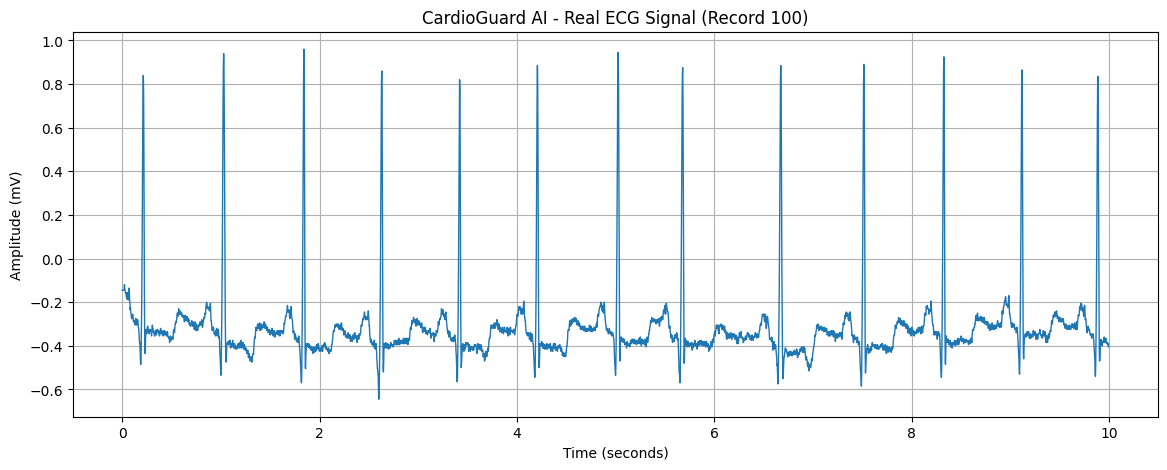

In [7]:
duration = 10
samples = int(duration * fs)

plt.figure(figsize=(14, 5))

plt.plot(
    time[:samples],
    ecg_signal[:samples],
    linewidth=1)

plt.title("CardioGuard AI - Real ECG Signal (Record 100)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

In [9]:
annotation = wfdb.rdann("100", "atr", pn_dir="mitdb")
print("Annotations loaded successfully!")
print("Total annotations:", len(annotation.sample))
print("\nFirst 20 annotation labels:")
print(annotation.symbol[:20])
print("\nFirst 20 annotation sample positions:")
print(annotation.sample[:20])

Annotations loaded successfully!
Total annotations: 2274

First 20 annotation labels:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']

First 20 annotation sample positions:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


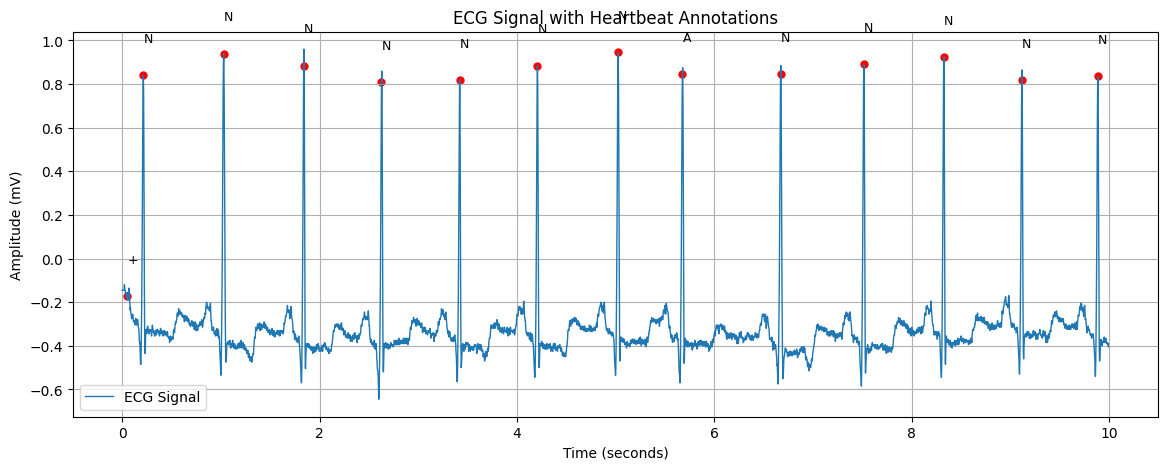

In [10]:
duration = 10
samples = int(duration * fs)
plt.figure(figsize=(14, 5))
plt.plot(
    time[:samples],
    ecg_signal[:samples],
    label="ECG Signal",
    linewidth=1)
for sample, symbol in zip(annotation.sample, annotation.symbol):
    if sample < samples:
        plt.scatter(
            time[sample],
            ecg_signal[sample],
            color="red",
            s=25)
        plt.text(
            time[sample],
            ecg_signal[sample] + 0.15,
            symbol,
            fontsize=9)
plt.title("ECG Signal with Heartbeat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
df = pd.DataFrame({"Time_seconds": time,"ECG_mV": ecg_signal})
df.to_csv("CardioGuard_ai/data/record_100.csv",index=False)
print("ECG signal saved successfully!")
print(df.head())
annotations_df = pd.DataFrame({"Sample": annotation.sample,"Time_seconds": annotation.sample / fs,"Label": annotation.symbol})
annotations_df.to_csv ("CardioGuard_ai/data/record_100_annotations.csv",index=False)
print("\nECG annotations saved successfully!")
print(annotations_df.head())

ECG signal saved successfully!
   Time_seconds  ECG_mV
0      0.000000  -0.145
1      0.002778  -0.145
2      0.005556  -0.145
3      0.008333  -0.145
4      0.011111  -0.145

ECG annotations saved successfully!
   Sample  Time_seconds Label
0      18      0.050000     +
1      77      0.213889     N
2     370      1.027778     N
3     662      1.838889     N
4     946      2.627778     N


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("CardioGuard_ai/data/record_100.csv")
annotations_df = pd.read_csv("CardioGuard_ai/data/record_100_annotations.csv")
ecg_signal = df["ECG_mV"].to_numpy()
annotation_samples = annotations_df["Sample"].to_numpy()
annotation_labels = annotations_df["Label"].to_numpy()
fs = 360
print("ECG data loaded successfully!")
print("Total ECG samples:", len(ecg_signal))
print("Total annotations:", len(annotation_samples))
print("Sampling frequency:", fs, "Hz")
print("ECG signal shape:", ecg_signal.shape)

ECG data loaded successfully!
Total ECG samples: 650000
Total annotations: 2274
Sampling frequency: 360 Hz
ECG signal shape: (650000,)


In [15]:
from scipy.signal import butter, sosfiltfilt
low_cutoff = 0.5
high_cutoff = 40
sos = butter(4,[low_cutoff, high_cutoff],btype="bandpass",fs=fs,output="sos")
filtered_ecg = sosfiltfilt(sos, ecg_signal)
print("ECG filtering completed!")
print("Original signal shape:", ecg_signal.shape)
print("Filtered signal shape:", filtered_ecg.shape)

ECG filtering completed!
Original signal shape: (650000,)
Filtered signal shape: (650000,)


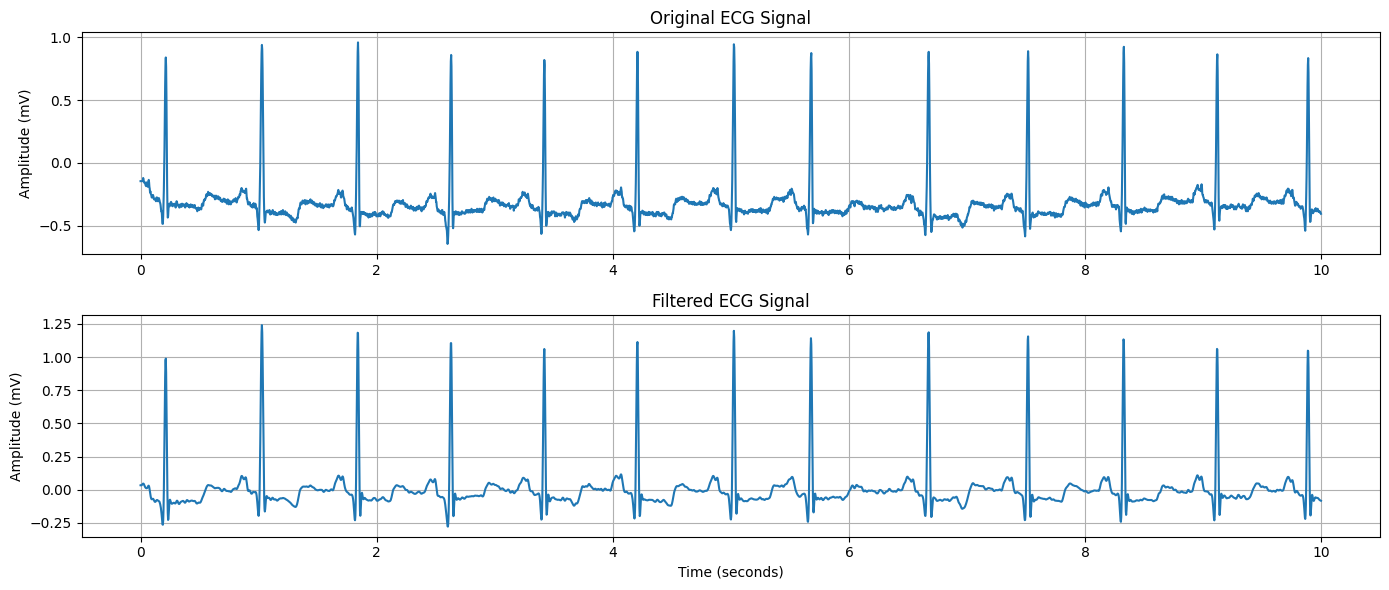

In [16]:
duration = 10
samples = int(duration * fs)
time = np.arange(samples) / fs
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(time, ecg_signal[:samples])
plt.title("Original ECG Signal")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(time, filtered_ecg[:samples])
plt.title("Filtered ECG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
before = int(0.2 * fs)
after = int(0.4 * fs)
segments = []
labels = []
normal_symbols = {"N", "L", "R", "e", "j"}
abnormal_symbols = {"A", "a", "J", "S", "V", "E", "F"}
for sample, symbol in zip(annotation_samples,annotation_labels):
    if symbol in normal_symbols:
        label = 0
    elif symbol in abnormal_symbols:
        label = 1
    else:
        continue
    start = sample - before
    end = sample + after
    if start < 0 or end > len(filtered_ecg):
        continue
    segment = filtered_ecg[start:end]
    if len(segment) == before + after:
        segments.append(segment)
        labels.append(label)
X = np.array(segments, dtype=np.float32)
y = np.array(labels, dtype=np.int64)
print("Heartbeat segmentation completed!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Normal beats:", np.sum(y == 0))
print("Abnormal beats:", np.sum(y == 1))

Heartbeat segmentation completed!
X shape: (2272, 216)
y shape: (2272,)
Normal beats: 2238
Abnormal beats: 34


In [18]:
import os
import numpy as np
os.makedirs("CardioGuard_ai/outputs",exist_ok=True)
np.save("CardioGuard_ai/outputs/X_segments.npy",X)
np.save("CardioGuard_ai/outputs/y_labels.npy",y)
print("Processed dataset saved successfully!")
print("File 1: X_segments.npy")
print("File 2: y_labels.npy")

Processed dataset saved successfully!
File 1: X_segments.npy
File 2: y_labels.npy


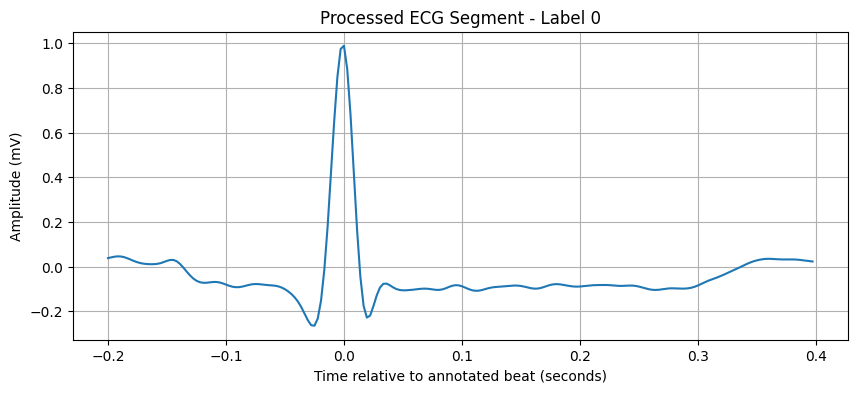

In [19]:
if len(X) > 0:
    segment_time = np.arange(X.shape[1]) / fs - 0.2
    plt.figure(figsize=(10, 4))
    plt.plot(segment_time, X[0])
    plt.title(f"Processed ECG Segment - Label {y[0]}")
    plt.xlabel("Time relative to annotated beat (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)
    plt.show()
else:
    print("No valid heartbeat segments found.")

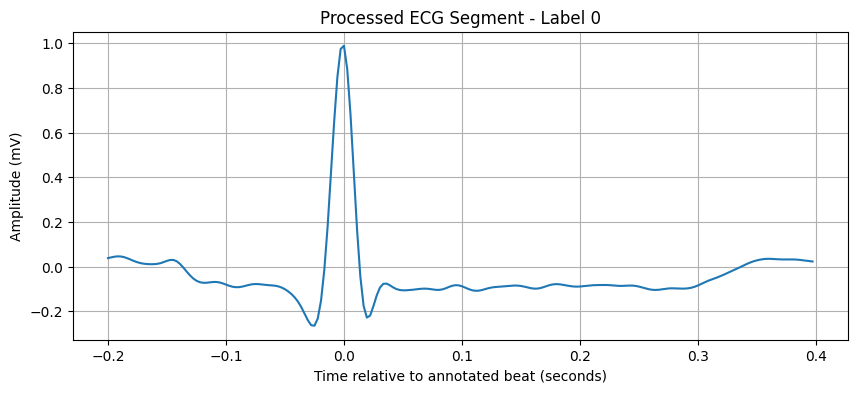

In [20]:
if len(X) > 0:
    segment_time = np.arange(X.shape[1]) / fs - 0.2
    plt.figure(figsize=(10, 4))
    plt.plot(segment_time, X[0])
    plt.title(f"Processed ECG Segment - Label {y[0]}")
    plt.xlabel("Time relative to annotated beat (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)
    plt.show()
else:
    print("No valid heartbeat segments found.")

In [22]:
from sklearn.model_selection import train_test_split
import numpy as np
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Data splitting completed!")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training normal:", np.sum(y_train == 0))
print("Training abnormal:", np.sum(y_train == 1))
print("Testing normal:", np.sum(y_test == 0))
print("Testing abnormal:", np.sum(y_test == 1))

Data splitting completed!
Training data shape: (1817, 216)
Testing data shape: (455, 216)
Training normal: 1790
Training abnormal: 27
Testing normal: 448
Testing abnormal: 7


In [23]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)
model.fit(X_train, y_train)
print("Model training completed!")
train_accuracy = model.score(X_train, y_train)
print("Training Accuracy:", round(train_accuracy * 100, 2), "%")

Model training completed!
Training Accuracy: 100.0 %


In [24]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score)
y_pred = model.predict(X_test)
print("MODEL EVALUATION RESULTS")
print("-" * 40)
print("Test Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Balanced Accuracy:",
      round(balanced_accuracy_score(y_test, y_pred) * 100, 2), "%")
print("F1 Score:",
      round(f1_score(y_test, y_pred, zero_division=0), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Normal", "Abnormal"],
    zero_division=0))

MODEL EVALUATION RESULTS
----------------------------------------
Test Accuracy: 98.9 %
Balanced Accuracy: 64.29 %
F1 Score: 0.4444

Confusion Matrix:
[[448   0]
 [  5   2]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       448
    Abnormal       1.00      0.29      0.44         7

    accuracy                           0.99       455
   macro avg       0.99      0.64      0.72       455
weighted avg       0.99      0.99      0.99       455



In [25]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score)
y_prob = model.predict_proba(X_test)[:, 1]
thresholds = [0.2, 0.3, 0.4, 0.5]
print("THRESHOLD ANALYSIS")
print("-" * 50)
for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels=[0, 1])
    print(f"\nThreshold: {threshold}")
    print("Confusion Matrix:")
    print(cm)
    print("Precision:",round(precision_score(y_test, y_pred_threshold, zero_division=0), 3))
    print("Recall:",round(recall_score(y_test, y_pred_threshold, zero_division=0), 3))
    print("F1 Score:",round(f1_score(y_test, y_pred_threshold, zero_division=0), 3))

THRESHOLD ANALYSIS
--------------------------------------------------

Threshold: 0.2
Confusion Matrix:
[[447   1]
 [  1   6]]
Precision: 0.857
Recall: 0.857
F1 Score: 0.857

Threshold: 0.3
Confusion Matrix:
[[448   0]
 [  3   4]]
Precision: 1.0
Recall: 0.571
F1 Score: 0.727

Threshold: 0.4
Confusion Matrix:
[[448   0]
 [  3   4]]
Precision: 1.0
Recall: 0.571
F1 Score: 0.727

Threshold: 0.5
Confusion Matrix:
[[448   0]
 [  5   2]]
Precision: 1.0
Recall: 0.286
F1 Score: 0.444


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score)
import numpy as np
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train)
print("Training samples:", len(X_fit))
print("Validation samples:", len(X_val))
print("Training abnormal:", np.sum(y_fit == 1))
print("Validation abnormal:", np.sum(y_val == 1))
model_val = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)
model_val.fit(X_fit, y_fit)
val_prob = model_val.predict_proba(X_val)[:, 1]
print("\nValidation model training completed!")
print("Validation probabilities generated:", len(val_prob))

Training samples: 1362
Validation samples: 455
Training abnormal: 20
Validation abnormal: 7

Validation model training completed!
Validation probabilities generated: 455


In [27]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score)
thresholds = [0.2, 0.3, 0.4, 0.5]
print("VALIDATION THRESHOLD ANALYSIS")
print("-" * 50)
for threshold in thresholds:
    y_val_pred = (val_prob >= threshold).astype(int)
    cm = confusion_matrix(
        y_val,
        y_val_pred,
        labels=[0, 1])
    print(f"\nThreshold: {threshold}")
    print("Confusion Matrix:")
    print(cm)
    print("Precision:",round(precision_score(y_val, y_val_pred, zero_division=0), 3))
    print("Recall:",round(recall_score(y_val, y_val_pred, zero_division=0), 3))
    print("F1 Score:",round(f1_score(y_val, y_val_pred, zero_division=0), 3))
    print("Balanced Accuracy:",round(balanced_accuracy_score(y_val, y_val_pred), 3))

VALIDATION THRESHOLD ANALYSIS
--------------------------------------------------

Threshold: 0.2
Confusion Matrix:
[[448   0]
 [  3   4]]
Precision: 1.0
Recall: 0.571
F1 Score: 0.727
Balanced Accuracy: 0.786

Threshold: 0.3
Confusion Matrix:
[[448   0]
 [  3   4]]
Precision: 1.0
Recall: 0.571
F1 Score: 0.727
Balanced Accuracy: 0.786

Threshold: 0.4
Confusion Matrix:
[[448   0]
 [  6   1]]
Precision: 1.0
Recall: 0.143
F1 Score: 0.25
Balanced Accuracy: 0.571

Threshold: 0.5
Confusion Matrix:
[[448   0]
 [  7   0]]
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Balanced Accuracy: 0.5


In [28]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score)
threshold = 0.2
test_prob = model_val.predict_proba(X_test)[:, 1]
y_test_pred = (test_prob >= threshold).astype(int)
print("FINAL TEST EVALUATION")
print("-" * 40)
print("Threshold:", threshold)
print("Test Accuracy:",
      round(accuracy_score(y_test, y_test_pred) * 100, 2), "%")
print("Balanced Accuracy:",
      round(balanced_accuracy_score(y_test, y_test_pred) * 100, 2), "%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred, labels=[0, 1]))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=["Normal", "Abnormal"],
    zero_division=0))

FINAL TEST EVALUATION
----------------------------------------
Threshold: 0.2
Test Accuracy: 99.56 %
Balanced Accuracy: 92.75 %

Confusion Matrix:
[[447   1]
 [  1   6]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       448
    Abnormal       0.86      0.86      0.86         7

    accuracy                           1.00       455
   macro avg       0.93      0.93      0.93       455
weighted avg       1.00      1.00      1.00       455



In [29]:
import os
import joblib
os.makedirs(
    "CardioGuard_ai/models",
    exist_ok=True)
model_path = "CardioGuard_ai/models/cardio_guard_rf.pkl"
joblib.dump(model_val, model_path)
print("Model saved successfully!")
print("Model path:", model_path)

Model saved successfully!
Model path: CardioGuard_ai/models/cardio_guard_rf.pkl


In [32]:
import os
print("Current directory:", os.getcwd())
for root, dirs, files in os.walk("/content"):
    for file in files:
        if "cardio_guard_rf" in file:
            print("Found:", os.path.join(root, file))

Current directory: /content
Found: /content/CardioGuard_ai/models/cardio_guard_rf.pkl


In [33]:
import joblib
model_path = "/content/CardioGuard_ai/models/cardio_guard_rf.pkl"
loaded_model = joblib.load(model_path)
print("Model loaded successfully!")
print("Model type:", type(loaded_model))

Model loaded successfully!
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [34]:
import numpy as np
def predict_heartbeat(ecg_segment):
    ecg_segment = np.array(ecg_segment).reshape(1, -1)
    if ecg_segment.shape[1] != 216:
        raise ValueError("ECG segment must contain 216 samples.")
    probability = loaded_model.predict_proba(ecg_segment)[0][1]
    threshold = 0.2
    if probability >= threshold:
        prediction = "Abnormal"
    else:
        prediction = "Normal"
    return {
        "Prediction": prediction,
        "Abnormal Probability": round(float(probability), 4)}
print("CardioGuard_ai prediction function ready!")

CardioGuard_ai prediction function ready!


In [35]:
sample_ecg = X_test[0]
result = predict_heartbeat(sample_ecg)
print("===== CardioGuard_ai =====")
print("Prediction:", result["Prediction"])
print("Abnormal Probability:", result["Abnormal Probability"])
print("Actual Label:", "Abnormal" if y_test[0] == 1 else "Normal")

===== CardioGuard_ai =====
Prediction: Normal
Abnormal Probability: 0.02
Actual Label: Normal


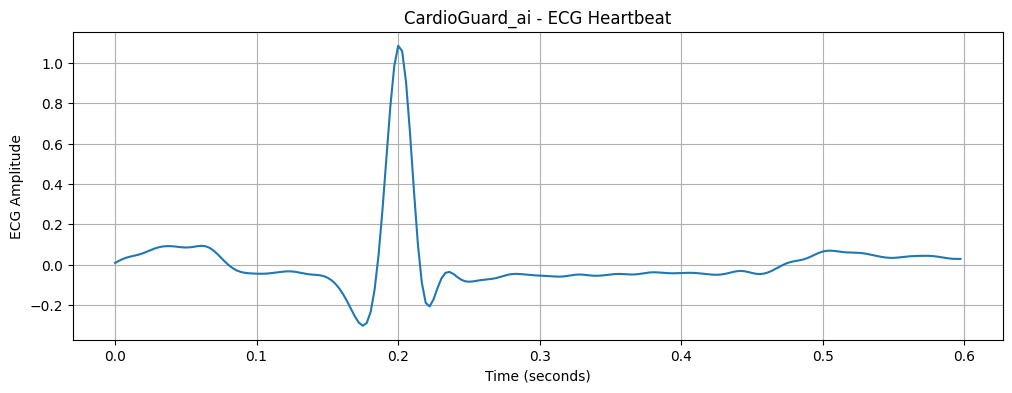

In [36]:
import matplotlib.pyplot as plt
import numpy as np
sample_ecg = np.array(X_test[0])
time = np.arange(len(sample_ecg)) / 360
plt.figure(figsize=(12, 4))
plt.plot(time, sample_ecg)
plt.title("CardioGuard_ai - ECG Heartbeat")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.grid(True)
plt.show()

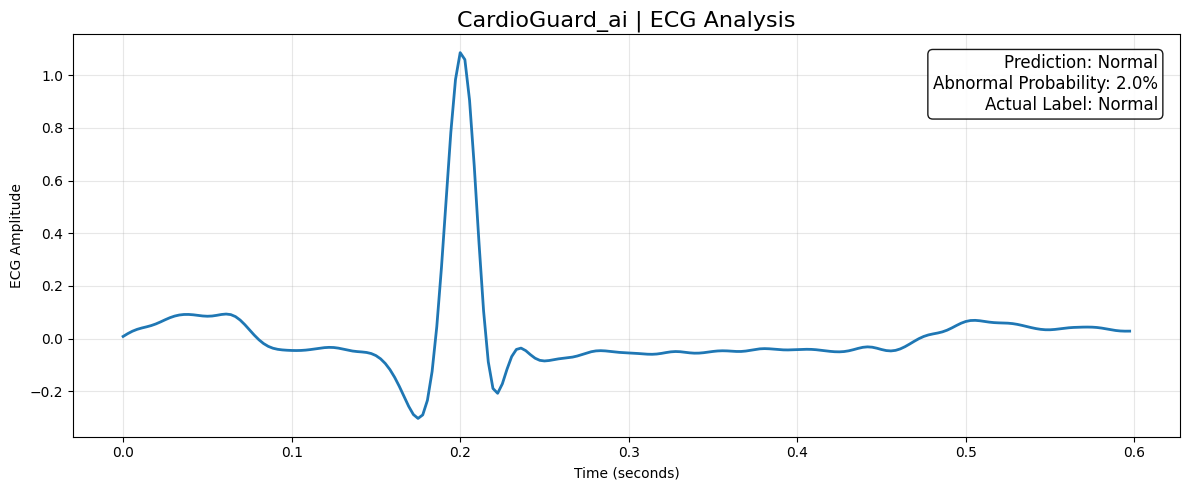

In [37]:
import numpy as np
import matplotlib.pyplot as plt
sample_ecg = X_test[0]
result = predict_heartbeat(sample_ecg)
time = np.arange(len(sample_ecg)) / 360
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time, sample_ecg, linewidth=2)
ax.set_title("CardioGuard_ai | ECG Analysis", fontsize=16)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("ECG Amplitude")
ax.grid(True, alpha=0.3)
info = (
    f"Prediction: {result['Prediction']}\n"
    f"Abnormal Probability: "
    f"{result['Abnormal Probability'] * 100:.1f}%\n"
    f"Actual Label: "
    f"{'Abnormal' if y_test[0] == 1 else 'Normal'}")
ax.text(
    0.98, 0.95, info,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
plt.tight_layout()
plt.show()

In [38]:
pip install gradio

In [39]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
def analyze_ecg(sample_index):
    sample_index = int(sample_index)
    ecg = X_test[sample_index]
    result = predict_heartbeat(ecg)
    actual = "Abnormal" if y_test[sample_index] == 1 else "Normal"
    time = np.arange(len(ecg)) / 360
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(time, ecg, linewidth=1.5)
    ax.set_title("CardioGuard_ai - ECG Analysis")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("ECG Amplitude")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return (
        result["Prediction"],
        result["Abnormal Probability"] * 100,
        actual,
        fig)
with gr.Blocks() as demo:
    gr.Markdown("# CardioGuard_ai")
    gr.Markdown("### ECG Heartbeat Analysis Dashboard")
    sample_input = gr.Slider(
        minimum=0,
        maximum=len(X_test) - 1,
        value=0,
        step=1,
        label="Select ECG Sample")
    analyze_btn = gr.Button("Analyze ECG")
    prediction = gr.Textbox(label="Predicted Class")
    probability = gr.Number(label="Abnormal Probability (%)")
    actual = gr.Textbox(label="Actual Label")
    graph = gr.Plot(label="ECG Waveform")
    analyze_btn.click(
        fn=analyze_ecg,
        inputs=sample_input,
        outputs=[prediction, probability, actual, graph])
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1beffd64e3fab330c5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [40]:
import numpy as np
abnormal_indices = np.where(y_test == 1)[0]
print("Total abnormal samples:", len(abnormal_indices))
print("First 10 abnormal sample indices:", abnormal_indices[:10])

Total abnormal samples: 7
First 10 abnormal sample indices: [ 30  89 112 158 203 291 389]


===== CardioGuard_ai Evaluation =====
Total Test Samples: 455
Accuracy: 99.56 %
Balanced Accuracy: 92.75 %

===== Classification Report =====
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       448
    Abnormal       0.86      0.86      0.86         7

    accuracy                           1.00       455
   macro avg       0.93      0.93      0.93       455
weighted avg       1.00      1.00      1.00       455



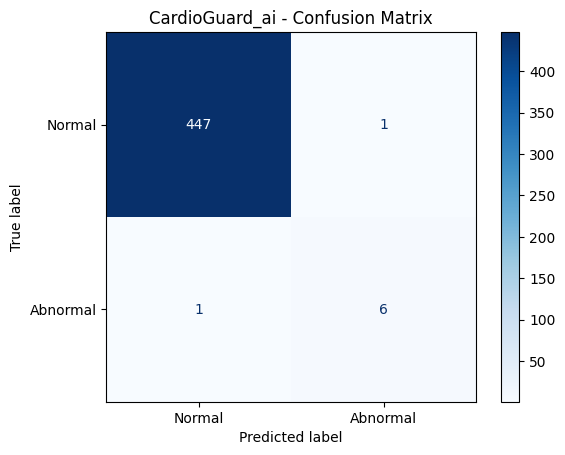

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay)
test_prob = loaded_model.predict_proba(X_test)[:, 1]
threshold = 0.2
y_test_pred = (test_prob >= threshold).astype(int)
print("===== CardioGuard_ai Evaluation =====")
print("Total Test Samples:", len(y_test))
print("Accuracy:", round(accuracy_score(y_test, y_test_pred) * 100, 2), "%")
print("Balanced Accuracy:", round(
    balanced_accuracy_score(y_test, y_test_pred) * 100, 2), "%")
print("\n===== Classification Report =====")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Normal", "Abnormal"],
    zero_division=0))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abnormal"])
disp.plot(cmap="Blues", values_format="d")
plt.title("CardioGuard_ai - Confusion Matrix")
plt.show()

In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
print("===== Confusion Matrix Results =====")
print("True Normal (TN):", tn)
print("False Abnormal (FP):", fp)
print("Missed Abnormal (FN):", fn)
print("Correct Abnormal (TP):", tp)

===== Confusion Matrix Results =====
True Normal (TN): 447
False Abnormal (FP): 1
Missed Abnormal (FN): 1
Correct Abnormal (TP): 6


In [43]:
import pandas as pd
report = pd.DataFrame({
    "Metric": [
        "Total Test Samples",
        "True Normal (TN)",
        "False Abnormal (FP)",
        "Missed Abnormal (FN)",
        "Correct Abnormal (TP)",
        "Accuracy (%)",
        "Balanced Accuracy (%)"],
    "Value": [
        len(y_test),
        tn,
        fp,
        fn,
        tp,
        99.56,
        92.75]})
report.to_csv(
    "CardioGuard_ai_evaluation_report.csv",
    index=False)
print("Evaluation report saved successfully!")
print(report)

Evaluation report saved successfully!
                  Metric   Value
0     Total Test Samples  455.00
1       True Normal (TN)  447.00
2    False Abnormal (FP)    1.00
3   Missed Abnormal (FN)    1.00
4  Correct Abnormal (TP)    6.00
5           Accuracy (%)   99.56
6  Balanced Accuracy (%)   92.75


In [44]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
def analyze_ecg(sample_index):
    sample_index = int(sample_index)
    ecg = X_test[sample_index]
    result = predict_heartbeat(ecg)
    actual = "Abnormal" if y_test[sample_index] == 1 else "Normal"
    time = np.arange(len(ecg)) / 360
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(time, ecg, linewidth=1.8)
    ax.set_title("ECG Heartbeat Waveform")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return (
        result["Prediction"],
        f'{result["Abnormal Probability"] * 100:.2f}%',
        actual,
        fig)
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # ❤️ CardioGuard_ai
    ### AI-Based ECG Heartbeat Classification
    Analyze ECG heartbeat segments and view the model's prediction.
    """)
    with gr.Row():
        sample_input = gr.Slider(
            minimum=0,
            maximum=len(X_test) - 1,
            value=0,
            step=1,
            label="Select ECG Sample")
    analyze_btn = gr.Button("🔍 Analyze ECG", variant="primary")

    with gr.Row():
        prediction = gr.Textbox(label="Predicted Class")
        probability = gr.Textbox(label="Abnormal Probability")
        actual = gr.Textbox(label="Dataset Label")
    graph = gr.Plot(label="ECG Waveform")
    analyze_btn.click(
        fn=analyze_ecg,
        inputs=sample_input,
        outputs=[prediction, probability, actual, graph]
    )
    gr.Markdown("""
    ---
    **Disclaimer:** This is an educational research prototype.
    It is not validated for clinical diagnosis or medical decisions.
    """)
demo.launch(share=True)

/tmp/ipykernel_1130/579120638.py:22: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0e0ea4662d395eab03.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
